# Markov Chain Graph Model for Stock Returns — Framework Design



## 1. Time Horizon / Regime Period

**Recommended frequency: Daily returns**

| Frequency | Markov suitability | Trading horizon | Practical notes |
|---|---|---|---|
| **Tick / 1-min** | Very noisy; microstructure dominates | Ultra-short (HFT) | Needs order-book data, latency constraints |
| **30-min / Hourly** | Intraday momentum exists but transitions are noisy | Intraday | High transaction cost relative to signal |
| **Daily** ✅ | Good balance of signal and sample size | Swing trading (1–10 days) | ~252 obs/year; easy to source; well-studied |
| **Weekly** | Smoother but fewer observations | Medium-term | ~52 obs/year — slow to estimate transitions |
| **Monthly** | Strong regime structure but tiny sample | Tactical allocation | Only ~12 obs/year |

### Why daily?
- **Sample size**: 5 years of daily data ≈ 1,260 observations — enough to estimate a 5×5 transition matrix (25 parameters) with ~50 transitions per cell on average.
- **Signal**: Daily returns exhibit mild autocorrelation, volatility clustering, and mean reversion — exactly the patterns a Markov chain can capture.
- **Actionability**: A daily trading signal is practical to execute with reasonable transaction costs.
- **Examination scope**: Aligns well with a short-horizon active strategy that can be backtested meaningfully.

## 2. Graph Representation of the Markov Chain

### 2.1 The directed weighted graph

A first-order Markov chain with $K$ states maps naturally to a **directed weighted graph** $G = (V, E, w)$:

- **Vertices** $V = \{s_1, \dots, s_K\}$: one node per discretised return state.
- **Directed edges** $E$: an edge $(s_i, s_j)$ exists if the estimated transition probability $\hat{p}_{ij} > 0$.
- **Edge weights** $w(s_i, s_j) = \hat{p}_{ij}$: the maximum-likelihood estimate of $P(S_{t+1} = s_j \mid S_t = s_i)$, computed as:

$$\hat{p}_{ij} = \frac{n_{ij}}{\sum_{k=1}^{K} n_{ik}}$$

where $n_{ij}$ = number of observed transitions from state $i$ to state $j$ in the training data.

### 2.2 The transition matrix as an adjacency matrix

The $K \times K$ transition matrix $\mathbf{P}$ is exactly the **weighted adjacency matrix** of the graph, where each row sums to 1 (a row-stochastic matrix).

$$
\mathbf{P} = \begin{pmatrix}
p_{11} & p_{12} & \cdots & p_{1K} \\
p_{21} & p_{22} & \cdots & p_{2K} \\
\vdots & & \ddots & \vdots \\
p_{K1} & p_{K2} & \cdots & p_{KK}
\end{pmatrix}
$$

### 2.3 Why is the graph view useful?

1. **Visualisation**: Drawing the graph with `networkx` makes regime dynamics immediately visible — you can see which states are "sticky" (strong self-loops) and which transitions dominate.

2. **Path analysis**: Graph algorithms (shortest path, PageRank, community detection) reveal structural properties:
   - **Stationary distribution** $\boldsymbol{\pi}$ (= PageRank with damping = 1): tells you the long-run fraction of time spent in each state.
   - **Mean first passage times**: how many days, on average, to reach a Large Up state from a Large Down state — computable via graph-theoretic formulas.
   - **Communicating classes**: if some states are transient, the graph decomposes into components.

3. **Optimisation on graphs**: Formulating trading as a flow or path problem on the graph opens access to well-studied combinatorial optimisation tools (see Section 6).

4. **Higher-order models**: A second-order Markov chain (conditioning on 2 past states) can be represented as a graph on $K^2$ nodes, where each node is a *pair* of consecutive states — the graph framework extends naturally.

## 3. Deriving a Trading Rule from Transition Probabilities

### 3.1 Core idea: Expected next-day return

Given the current state $s_i$, compute the **conditional expected return** for tomorrow:

$$\hat{\mu}_i = \sum_{j=1}^{K} \hat{p}_{ij} \cdot \bar{r}_j$$

where $\bar{r}_j$ is the **average realised return** within state $j$ (computed from training data). This is the expected return of holding the asset for one day, conditional on being in state $s_i$ today.

### 3.2 Simple threshold rule

$$
\text{Position}_{t+1} = 
\begin{cases}
+1 \;\text{(long)} & \text{if } \hat{\mu}_{s_t} > c \\
0 \;\text{(flat)} & \text{if } |\hat{\mu}_{s_t}| \le c \\
-1 \;\text{(short)} & \text{if } \hat{\mu}_{s_t} < -c
\end{cases}
$$

where $c \ge 0$ is a **transaction-cost buffer** (e.g. $c = 0.05\%$ to avoid trading on tiny edges). If short-selling is not permitted, replace $-1$ with $0$.

### 3.3 Probability-weighted rule (risk-aware)

Instead of just the expected return, incorporate the **probability of a favourable move**:

$$P(\text{up} \mid s_i) = \sum_{j : \bar{r}_j > 0} \hat{p}_{ij}$$

Go long only when *both* $\hat{\mu}_i > c$ **and** $P(\text{up} \mid s_i) > 0.5$. This avoids states where a small probability of a huge gain inflates the expected return but the most likely outcome is negative.

### 3.4 Multi-step lookahead

The Markov property allows you to compute the **$n$-step transition matrix** $\mathbf{P}^n$ and derive expected returns over a horizon of $n$ days:

$$\hat{\mu}_i^{(n)} = \sum_{j=1}^K [\mathbf{P}^n]_{ij} \cdot \bar{r}_j$$

This is useful for a strategy that holds positions for more than one day. The graph interpretation: $[\mathbf{P}^n]_{ij}$ is the probability of a length-$n$ walk from node $i$ to node $j$.

## 4. Summary Pipeline

```
Raw price data
     │
     ▼
Compute daily log-returns  r_t = ln(P_t / P_{t-1})
     │
     ▼
Chronological train/test split
     │
     ▼
Discretise returns into K states using training-set quantiles
     │
     ▼
Count transitions  n_{ij}  →  estimate  P̂_{ij} = n_{ij} / Σ_k n_{ik}
     │
     ▼
Build directed weighted graph  G = (V, E, w)
     │
     ▼
Analyse graph: stationary distribution, mean passage times, PageRank
     │
     ▼
Solve MDP / derive trading rule from conditional expected returns
     │
     ▼
Backtest on test set  →  compute Sharpe, drawdown, hit rate
     │
     ▼
Compare to buy-and-hold benchmark
```

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# ── 1. Load data and compute returns ──────────────────────────────────────────
df = pd.read_csv("snp_500_2015_2019.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
df = df.dropna(subset=["log_return"]).reset_index(drop=True)

print(f"Date range: {df['Date'].iloc[0].date()} to {df['Date'].iloc[-1].date()}")
print(f"Total observations: {len(df)}")
df[["Date", "Close", "log_return"]].head(10)

Total observations: 1509
Date range: 2014-01-03 to 2019-12-31


In [47]:
# ── 2. Train / Test split ──────────────────────────────────────────────────────
# Data runs 2014-01-02 to 2019-12-31
train_end = "2017-12-31"
val_end = "2018-12-31"

train = df[df["Date"] <= train_end].copy()
val = df[(df["Date"] > train_end) & (df["Date"] <= val_end)].copy()
test = df[df["Date"] > val_end].copy()

print(f"Train: {len(train)} days  ({train['Date'].iloc[0].date()} to {train['Date'].iloc[-1].date()})")
print(f"Val:   {len(val)} days  ({val['Date'].iloc[0].date()} to {val['Date'].iloc[-1].date()})")
print(f"Test:  {len(test)} days  ({test['Date'].iloc[0].date()} to {test['Date'].iloc[-1].date()})")

Train: 1006 days  (2014-01-03 to 2017-12-29)
Val:   251 days  (2018-01-02 to 2018-12-31)
Test:  252 days  (2019-01-02 to 2019-12-31)


In [51]:
# ── 3. Discretise returns into K states (quantile-based) ──────────────────────
K = 5
state_labels = ["Large Down", "Small Down", "Flat", "Small Up", "Large Up"]

# Compute quantile boundaries from TRAINING data only (no look-ahead bias)
quantiles = [0.0, 0.10, 0.40, 0.60, 0.90, 1.0]
boundaries = train["log_return"].quantile(quantiles).values.copy()
boundaries[0] = -np.inf
boundaries[-1] = np.inf

print("State boundaries (from training set):")
for i in range(K):
    lo = boundaries[i]
    hi = boundaries[i + 1]
    print(f"  {state_labels[i]:12s}: [{lo:+.4f}, {hi:+.4f})")

def discretise(returns, boundaries):
    """Assign each return to a state index 0..K-1."""
    states = np.digitize(returns, boundaries[1:-1])  # bins: 0, 1, ..., K-1
    return states

train["state"] = discretise(train["log_return"].values, boundaries)
val["state"] = discretise(val["log_return"].values, boundaries)
test["state"] = discretise(test["log_return"].values, boundaries)

# Check bin counts
print("\nTraining set state counts:")
for i in range(K):
    count = (train["state"] == i).sum()
    print(f"  {state_labels[i]:12s}: {count:4d} ({count/len(train)*100:.1f}%)")

State boundaries (from training set):
  Large Down  : [-inf, -0.0084)
  Small Down  : [-0.0084, -0.0007)
  Flat        : [-0.0007, +0.0016)
  Small Up    : [+0.0016, +0.0091)
  Large Up    : [+0.0091, +inf)

Training set state counts:
  Large Down  :  101 (10.0%)
  Small Down  :  301 (29.9%)
  Flat        :  201 (20.0%)
  Small Up    :  302 (30.0%)
  Large Up    :  101 (10.0%)


In [52]:
# ── 4. Estimate transition matrix ─────────────────────────────────────────────
def estimate_transition_matrix(states, K, alpha=0.0):
    """
    Maximum-likelihood transition matrix with optional Laplace smoothing.
    alpha=0: pure MLE.  alpha>0: Bayesian smoothing.
    """
    counts = np.zeros((K, K))
    for t in range(len(states) - 1):
        i, j = states[t], states[t + 1]
        counts[i, j] += 1
    # Add smoothing
    counts += alpha
    # Normalise rows
    row_sums = counts.sum(axis=1, keepdims=True)
    P = counts / row_sums
    return P, counts - alpha  # return raw counts too

P_train, counts_train = estimate_transition_matrix(train["state"].values, K, alpha=1.0)

print("Transition count matrix:")
count_df = pd.DataFrame(counts_train.astype(int), index=state_labels, columns=state_labels)
print(count_df)
print("\nTransition probability matrix (with Laplace smoothing α=1):")
prob_df = pd.DataFrame(P_train.round(3), index=state_labels, columns=state_labels)
print(prob_df)

Transition count matrix:
            Large Down  Small Down  Flat  Small Up  Large Up
Large Down          19          16    16        26        24
Small Down          22          79    60       109        30
Flat                21          67    38        59        16
Small Up            21         111    70        83        17
Large Up            18          28    16        25        14

Transition probability matrix (with Laplace smoothing α=1):
            Large Down  Small Down   Flat  Small Up  Large Up
Large Down       0.189       0.160  0.160     0.255     0.236
Small Down       0.075       0.262  0.200     0.361     0.102
Flat             0.107       0.330  0.189     0.291     0.083
Small Up         0.072       0.365  0.231     0.274     0.059
Large Up         0.179       0.274  0.160     0.245     0.142


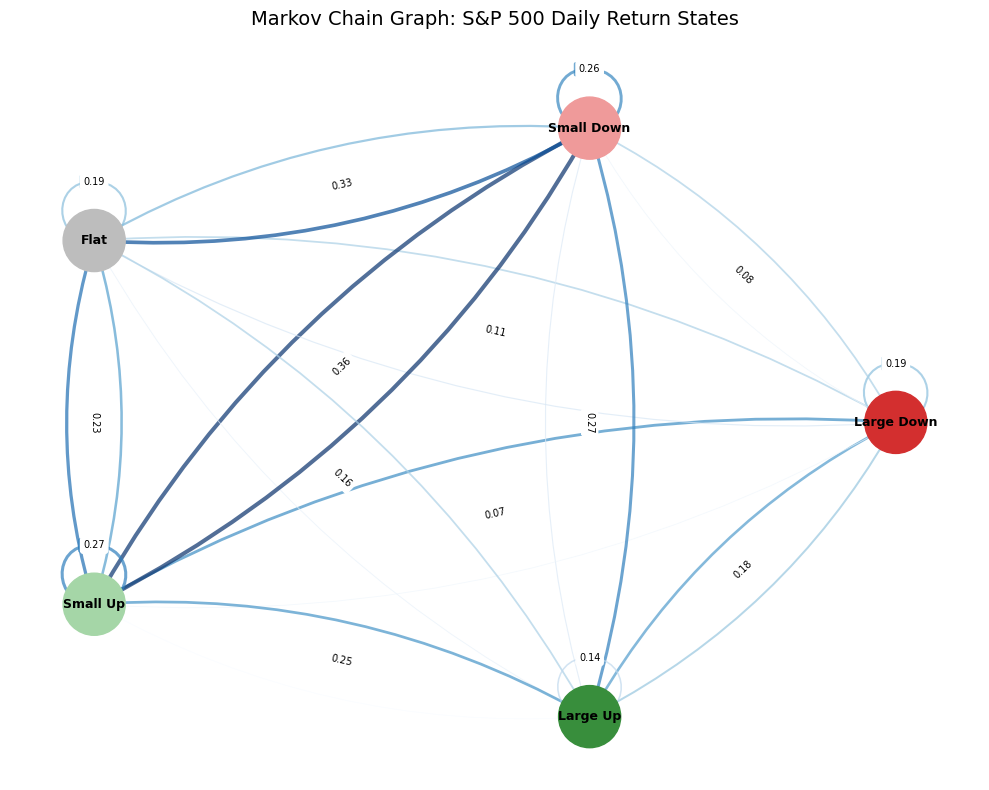

In [53]:
# ── 5. Build and visualise the Markov chain graph ─────────────────────────────
G = nx.DiGraph()

for i in range(K):
    G.add_node(i, label=state_labels[i])

for i in range(K):
    for j in range(K):
        if P_train[i, j] > 0.01:  # only draw edges with meaningful probability
            G.add_edge(i, j, weight=P_train[i, j])

# Layout and drawing
fig, ax = plt.subplots(figsize=(10, 8))
pos = nx.circular_layout(G)

# Node colours: red for down states, grey for flat, green for up states
node_colors = ["#d32f2f", "#ef9a9a", "#bdbdbd", "#a5d6a7", "#388e3c"]

nx.draw_networkx_nodes(G, pos, node_size=2000, node_color=node_colors, ax=ax)
nx.draw_networkx_labels(G, pos, labels={i: state_labels[i] for i in range(K)},
                        font_size=9, font_weight="bold", ax=ax)

# Draw edges with width proportional to probability
edges = G.edges(data=True)
edge_widths = [d["weight"] * 8 for _, _, d in edges]
edge_colors = [d["weight"] for _, _, d in edges]

nx.draw_networkx_edges(G, pos, edgelist=[(u, v) for u, v, _ in edges],
                       width=edge_widths, edge_color=edge_colors,
                       edge_cmap=plt.cm.Blues, alpha=0.7,
                       arrows=True, arrowsize=20,
                       connectionstyle="arc3,rad=0.15", ax=ax)

# Edge labels (probabilities)
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, ax=ax)

ax.set_title("Markov Chain Graph: S&P 500 Daily Return States", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

In [54]:
# ── 6. Graph analysis: stationary distribution & mean first passage times ─────

# 6a. Stationary distribution (left eigenvector of P with eigenvalue 1)
eigenvalues, eigenvectors = np.linalg.eig(P_train.T)
# Find eigenvector for eigenvalue closest to 1
idx = np.argmin(np.abs(eigenvalues - 1.0))
stationary = np.real(eigenvectors[:, idx])
stationary = stationary / stationary.sum()  # normalise to sum to 1

print("Stationary distribution (long-run fraction of time in each state):")
for i in range(K):
    print(f"  {state_labels[i]:12s}: {stationary[i]:.4f} ({stationary[i]*100:.1f}%)")

# 6b. Mean first passage times (expected days to reach state j from state i)
# Solve: M[i,j] = 1 + Σ_{k≠j} P[i,k] * M[k,j]
def mean_first_passage(P):
    K = P.shape[0]
    M = np.zeros((K, K))
    for j in range(K):
        # For target state j, solve (I - Q) m = 1, where Q = P with column/row j removed
        mask = [k for k in range(K) if k != j]
        Q = P[np.ix_(mask, mask)]
        ones = np.ones(K - 1)
        m = np.linalg.solve(np.eye(K - 1) - Q, ones)
        for idx_m, k in enumerate(mask):
            M[k, j] = m[idx_m]
    return M

M = mean_first_passage(P_train)
print("\nMean first passage times (expected days to reach column state from row state):")
mfp_df = pd.DataFrame(M.round(1), index=state_labels, columns=state_labels)
print(mfp_df)

Stationary distribution (long-run fraction of time in each state):
  Large Down  : 0.1029 (10.3%)
  Small Down  : 0.2970 (29.7%)
  Flat        : 0.1990 (19.9%)
  Small Up    : 0.2981 (29.8%)
  Large Up    : 0.1029 (10.3%)

Mean first passage times (expected days to reach column state from row state):
            Large Down  Small Down  Flat  Small Up  Large Up
Large Down         0.0         3.8   5.2       3.5       8.7
Small Down        11.1         0.0   5.0       3.1      10.3
Flat              10.8         3.2   0.0       3.3      10.5
Small Up          11.2         3.0   4.8       0.0      10.8
Large Up           9.9         3.4   5.2       3.5       0.0


In [55]:
# ── 7. Trading rule: conditional expected return ──────────────────────────────

# Average realised return in each state (training set)
state_mean_return = train.groupby("state")["log_return"].mean().values
print("Mean return per state (training set):")
for i in range(K):
    print(f"  {state_labels[i]:12s}: {state_mean_return[i]*100:+.3f}%")

# Conditional expected next-day return given current state
cond_expected = P_train @ state_mean_return
print("\nConditional expected next-day return E[r_{t+1} | state_t = s_i]:")
for i in range(K):
    print(f"  {state_labels[i]:12s}: {cond_expected[i]*100:+.4f}%")

# P(next day up | current state)
prob_up = P_train[:, 3:].sum(axis=1)  # states "Small Up" + "Large Up"
print("\nP(up move tomorrow | current state):")
for i in range(K):
    print(f"  {state_labels[i]:12s}: {prob_up[i]:.3f}")

Mean return per state (training set):
  Large Down  : -1.455%
  Small Down  : -0.328%
  Flat        : +0.041%
  Small Up    : +0.448%
  Large Up    : +1.387%

Conditional expected next-day return E[r_{t+1} | state_t = s_i]:
  Large Down  : +0.1205%
  Small Down  : +0.1149%
  Flat        : -0.0111%
  Small Up    : -0.0107%
  Large Up    : -0.0380%

P(up move tomorrow | current state):
  Large Down  : 0.491
  Small Down  : 0.462
  Flat        : 0.374
  Small Up    : 0.332
  Large Up    : 0.387


In [56]:
# ── 7b. Validation: tune K (number of states) and alpha (smoothing) ───────────
# The validation set is used to select the best hyperparameters before
# evaluating on the held-out test set.
#
# Parameters being tuned:
#   K     — number of discretised return states (controls granularity)
#   alpha — Laplace smoothing strength (controls regularisation of transition matrix)

K_candidates = [3, 5, 7]
alpha_candidates = [0, 0.5, 1.0, 2.0]

results = []

for K_try in K_candidates:
    # Define quantile boundaries for K_try states
    q = np.linspace(0, 1, K_try + 1)
    # Use asymmetric quantiles for tail-heavy bins when K=5
    if K_try == 5:
        q = [0.0, 0.10, 0.40, 0.60, 0.90, 1.0]
    bounds = train["log_return"].quantile(q).values.copy()
    bounds[0] = -np.inf
    bounds[-1] = np.inf

    train_states = np.digitize(train["log_return"].values, bounds[1:-1])
    val_states = np.digitize(val["log_return"].values, bounds[1:-1])

    # Mean return per state from training set
    smr = np.array([train["log_return"].values[train_states == s].mean()
                     for s in range(K_try)])

    for alpha_try in alpha_candidates:
        P, _ = estimate_transition_matrix(train_states, K_try, alpha=alpha_try)

        # Solve MDP (no transaction costs)
        V = np.zeros(K_try)
        for _ in range(5000):
            V_new = np.zeros(K_try)
            pol = np.zeros(K_try, dtype=int)
            for i in range(K_try):
                best_val, best_a = -np.inf, 0
                for a in [-1, 0, 1]:
                    reward = a * (P[i] @ smr)
                    v = reward + 0.99 * (P[i] @ V)
                    if v > best_val:
                        best_val, best_a = v, a
                V_new[i] = best_val
                pol[i] = best_a
            if np.max(np.abs(V_new - V)) < 1e-8:
                break
            V = V_new

        # Backtest on validation set
        val_rets = []
        for t in range(len(val_states) - 1):
            pos = pol[val_states[t]]
            val_rets.append(pos * val["log_return"].iloc[t + 1])
        val_rets = np.array(val_rets)

        sharpe = (np.mean(val_rets) / np.std(val_rets) * np.sqrt(252)
                  if np.std(val_rets) > 0 else 0)
        total_ret = np.exp(np.sum(val_rets)) - 1
        results.append({
            "K": K_try, "alpha": alpha_try,
            "sharpe": sharpe, "total_return": total_ret,
            "policy": {s: {-1: "SHORT", 0: "FLAT", 1: "LONG"}[pol[s]] for s in range(K_try)}
        })

results_df = pd.DataFrame(results).sort_values("sharpe", ascending=False)
print("Validation set results (sorted by Sharpe):\n")
print(results_df[["K", "alpha", "sharpe", "total_return"]].to_string(index=False))

best = results_df.iloc[0]
print(f"\nBest: K={int(best['K'])}, alpha={best['alpha']}, "
      f"Sharpe={best['sharpe']:.3f}, Return={best['total_return']*100:+.2f}%")
print(f"Policy: {best['policy']}")

Validation set results (sorted by Sharpe):

 K  alpha    sharpe  total_return
 7    0.0  0.073832      0.012592
 7    0.5  0.073832      0.012592
 7    1.0  0.073832      0.012592
 7    2.0  0.073832      0.012592
 5    2.0 -0.594847     -0.095835
 5    1.0 -0.594847     -0.095835
 5    0.5 -0.594847     -0.095835
 5    0.0 -0.594847     -0.095835
 3    2.0 -1.823213     -0.264333
 3    1.0 -1.823213     -0.264333
 3    0.5 -1.823213     -0.264333
 3    0.0 -1.823213     -0.264333

Best: K=7, alpha=0.0, Sharpe=0.074, Return=+1.26%
Policy: {0: 'LONG', 1: 'LONG', 2: 'LONG', 3: 'SHORT', 4: 'SHORT', 5: 'LONG', 6: 'SHORT'}


In [57]:
# ── 7c. Re-fit with best hyperparameters from validation ──────────────────────
best_K = int(best["K"])
best_alpha = best["alpha"]
print(f"Re-fitting with K={best_K}, alpha={best_alpha}\n")

# Recompute quantile boundaries
if best_K == 5:
    quantiles = [0.0, 0.10, 0.40, 0.60, 0.90, 1.0]
else:
    quantiles = np.linspace(0, 1, best_K + 1).tolist()
boundaries = train["log_return"].quantile(quantiles).values.copy()
boundaries[0] = -np.inf
boundaries[-1] = np.inf

K = best_K
state_labels = [f"State {i}" for i in range(K)]
if K == 3:
    state_labels = ["Down", "Flat", "Up"]
elif K == 5:
    state_labels = ["Large Down", "Small Down", "Flat", "Small Up", "Large Up"]
elif K == 7:
    state_labels = ["Large Down", "Med Down", "Small Down", "Flat",
                    "Small Up", "Med Up", "Large Up"]

train["state"] = discretise(train["log_return"].values, boundaries)
val["state"] = discretise(val["log_return"].values, boundaries)
test["state"] = discretise(test["log_return"].values, boundaries)

P_train, counts_train = estimate_transition_matrix(train["state"].values, K, alpha=best_alpha)
state_mean_return = np.array([train.loc[train["state"] == s, "log_return"].mean()
                              for s in range(K)])

print("Updated transition matrix:")
print(pd.DataFrame(P_train.round(3), index=state_labels, columns=state_labels))
print("\nMean return per state:")
for i in range(K):
    print(f"  {state_labels[i]:12s}: {state_mean_return[i]*100:+.3f}%")

Re-fitting with K=7, alpha=0.0

Updated transition matrix:
            Large Down  Med Down  Small Down   Flat  Small Up  Med Up  \
Large Down       0.208     0.111       0.069  0.097     0.104   0.167   
Med Down         0.126     0.119       0.098  0.168     0.147   0.140   
Small Down       0.112     0.112       0.154  0.147     0.203   0.154   
Flat             0.132     0.208       0.160  0.111     0.139   0.125   
Small Up         0.147     0.154       0.154  0.224     0.119   0.133   
Med Up           0.076     0.146       0.208  0.160     0.160   0.167   
Large Up         0.201     0.153       0.153  0.090     0.125   0.118   

            Large Up  
Large Down     0.243  
Med Down       0.203  
Small Down     0.119  
Flat           0.125  
Small Up       0.070  
Med Up         0.083  
Large Up       0.160  

Mean return per state:
  Large Down  : -1.234%
  Med Down    : -0.366%
  Small Down  : -0.118%
  Flat        : +0.040%
  Small Up    : +0.221%
  Med Up      : +0.508%
  La

In [ ]:
# ── 7d. Markov chain graph for K=7 ─────────────────────────────────────────────
K7 = 7
state_labels_7 = ["Large Down", "Med Down", "Small Down", "Flat",
                  "Small Up", "Med Up", "Large Up"]

# Quantile boundaries for 7 states
q7 = np.linspace(0, 1, K7 + 1)
bounds_7 = train["log_return"].quantile(q7).values.copy()
bounds_7[0] = -np.inf
bounds_7[-1] = np.inf

train_states_7 = np.digitize(train["log_return"].values, bounds_7[1:-1])
P7, _ = estimate_transition_matrix(train_states_7, K7, alpha=best_alpha)

# Build directed graph
G7 = nx.DiGraph()
for i in range(K7):
    G7.add_node(i, label=state_labels_7[i])
for i in range(K7):
    for j in range(K7):
        if P7[i, j] > 0.01:
            G7.add_edge(i, j, weight=P7[i, j])

# Visualise
fig, ax = plt.subplots(figsize=(12, 10))
pos = nx.circular_layout(G7)

node_colors_7 = ["#b71c1c", "#d32f2f", "#ef9a9a", "#bdbdbd",
                  "#a5d6a7", "#388e3c", "#1b5e20"]

nx.draw_networkx_nodes(G7, pos, node_size=2000, node_color=node_colors_7, ax=ax)
nx.draw_networkx_labels(G7, pos, labels={i: state_labels_7[i] for i in range(K7)},
                        font_size=8, font_weight="bold", ax=ax)

edges = G7.edges(data=True)
edge_widths = [d["weight"] * 8 for _, _, d in edges]
edge_colors = [d["weight"] for _, _, d in edges]

nx.draw_networkx_edges(G7, pos, edgelist=[(u, v) for u, v, _ in edges],
                       width=edge_widths, edge_color=edge_colors,
                       edge_cmap=plt.cm.Blues, alpha=0.7,
                       arrows=True, arrowsize=20,
                       connectionstyle="arc3,rad=0.15", ax=ax)

edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in edges}
nx.draw_networkx_edge_labels(G7, pos, edge_labels=edge_labels, font_size=6, ax=ax)

ax.set_title("Markov Chain Graph: S&P 500 Daily Return States (K=7)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

print("\nTransition matrix (K=7):")
print(pd.DataFrame(P7.round(3), index=state_labels_7, columns=state_labels_7))

In [58]:
# ── 8. MDP optimisation: value iteration ──────────────────────────────────────

def solve_mdp(P, state_mean_return, actions=[-1, 0, 1],
              gamma=0.99, tol=1e-8, max_iter=10000):
    """
    Solve the MDP via value iteration (no transaction costs).
    Reward for taking action a in state i = a * E[r_{t+1} | s_t = i].
    """
    K = P.shape[0]
    V = np.zeros(K)

    for iteration in range(max_iter):
        V_new = np.zeros(K)
        policy = np.zeros(K, dtype=int)
        for i in range(K):
            best_val = -np.inf
            best_a = 0
            for a in actions:
                reward = a * (P[i] @ state_mean_return)
                val = reward + gamma * (P[i] @ V)
                if val > best_val:
                    best_val = val
                    best_a = a
            V_new[i] = best_val
            policy[i] = best_a
        if np.max(np.abs(V_new - V)) < tol:
            print(f"Value iteration converged in {iteration + 1} iterations.")
            break
        V = V_new

    return policy, V

optimal_policy, V_star = solve_mdp(P_train, state_mean_return)

print("\nOptimal policy (MDP solution):")
action_labels = {-1: "SHORT", 0: "FLAT", 1: "LONG"}
for i in range(K):
    print(f"  {state_labels[i]:12s} → {action_labels[optimal_policy[i]]:5s}  (value: {V_star[i]:.6f})")

Value iteration converged in 1112 iterations.

Optimal policy (MDP solution):
  Large Down   → LONG   (value: 0.070396)
  Med Down     → LONG   (value: 0.070808)
  Small Down   → LONG   (value: 0.070132)
  Flat         → SHORT  (value: 0.069549)
  Small Up     → SHORT  (value: 0.070072)
  Med Up       → LONG   (value: 0.069943)
  Large Up     → SHORT  (value: 0.069833)


In [59]:
# ── 9. Backtest on test set ────────────────────────────────────────────────────

def backtest(data, policy):
    """
    Backtest a Markov-chain trading strategy (no transaction costs).
    Position is determined by the MDP policy given the current state.
    Return is position * next-day log-return.
    """
    positions = []
    returns_strat = []

    for t in range(len(data)):
        state = data["state"].iloc[t]
        pos = policy[state]

        if t < len(data) - 1:
            next_ret = data["log_return"].iloc[t + 1]
            returns_strat.append(pos * next_ret)
        positions.append(pos)

    return np.array(returns_strat), np.array(positions)

# Run backtest on test set
strat_returns, strat_positions = backtest(test, optimal_policy)
benchmark_returns = test["log_return"].iloc[1:].values  # buy-and-hold

def compute_metrics(returns, label="Strategy"):
    cum_ret = np.exp(np.cumsum(returns)) - 1
    ann_ret = np.mean(returns) * 252
    ann_vol = np.std(returns) * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    max_dd = np.min(cum_ret - np.maximum.accumulate(cum_ret))
    hit_rate = np.mean(returns > 0)
    print(f"\n{label}:")
    print(f"  Annualised return:  {ann_ret*100:+.2f}%")
    print(f"  Annualised vol:     {ann_vol*100:.2f}%")
    print(f"  Sharpe ratio:       {sharpe:.3f}")
    print(f"  Max drawdown:       {max_dd*100:.2f}%")
    print(f"  Hit rate:           {hit_rate*100:.1f}%")
    print(f"  Total return:       {cum_ret[-1]*100:+.2f}%")
    return cum_ret

cum_strat = compute_metrics(strat_returns, "Markov Chain MDP Strategy")
cum_bench = compute_metrics(benchmark_returns, "Buy & Hold Benchmark")


Markov Chain MDP Strategy:
  Annualised return:  +4.44%
  Annualised vol:     12.59%
  Sharpe ratio:       0.353
  Max drawdown:       -12.62%
  Hit rate:           49.4%
  Total return:       +4.52%

Buy & Hold Benchmark:
  Annualised return:  +25.34%
  Annualised vol:     12.49%
  Sharpe ratio:       2.029
  Max drawdown:       -8.02%
  Hit rate:           59.4%
  Total return:       +28.71%


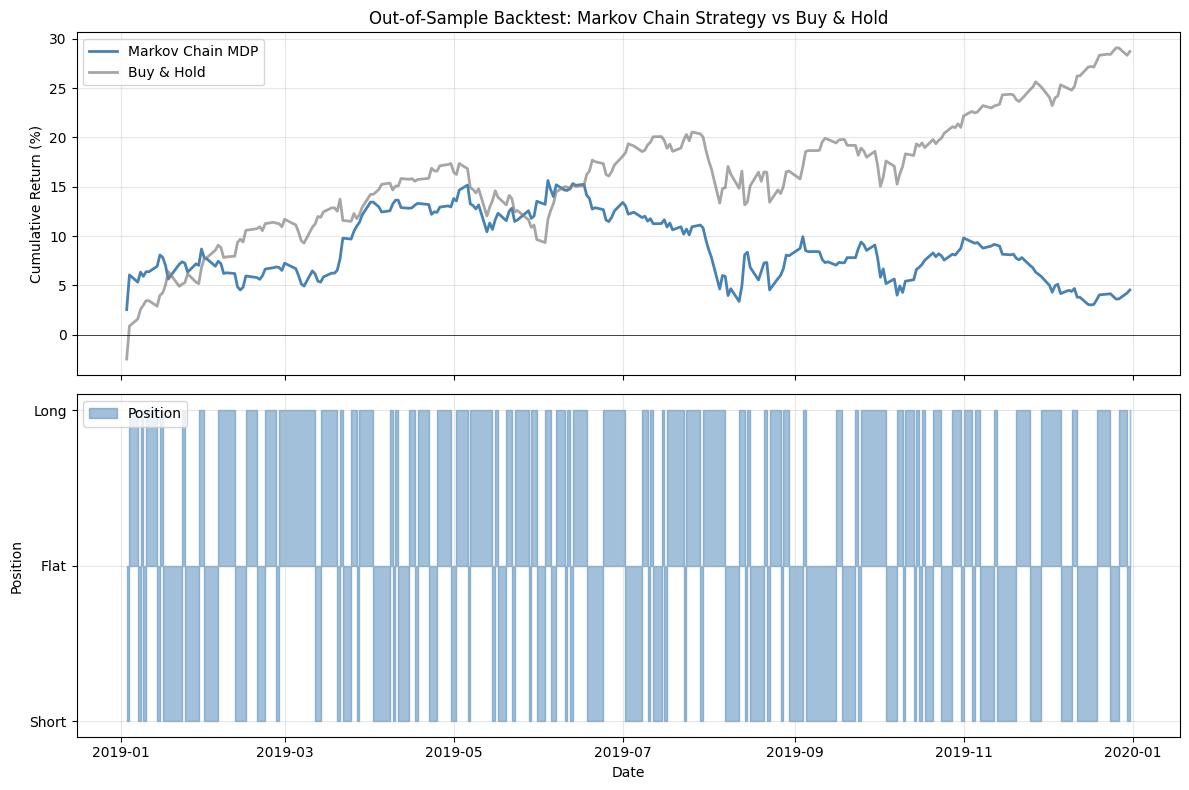

In [60]:
# ── 10. Plot cumulative returns ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Cumulative returns
dates = test["Date"].iloc[1:].values
axes[0].plot(dates, cum_strat * 100, label="Markov Chain MDP", linewidth=2, color="steelblue")
axes[0].plot(dates, cum_bench * 100, label="Buy & Hold", linewidth=2, color="grey", alpha=0.7)
axes[0].set_ylabel("Cumulative Return (%)")
axes[0].set_title("Out-of-Sample Backtest: Markov Chain Strategy vs Buy & Hold")
axes[0].legend()
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].grid(True, alpha=0.3)

# Positions over time
axes[1].fill_between(dates, strat_positions[:len(dates)], alpha=0.5, color="steelblue",
                     step="post", label="Position")
axes[1].set_ylabel("Position")
axes[1].set_xlabel("Date")
axes[1].set_yticks([-1, 0, 1])
axes[1].set_yticklabels(["Short", "Flat", "Long"])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

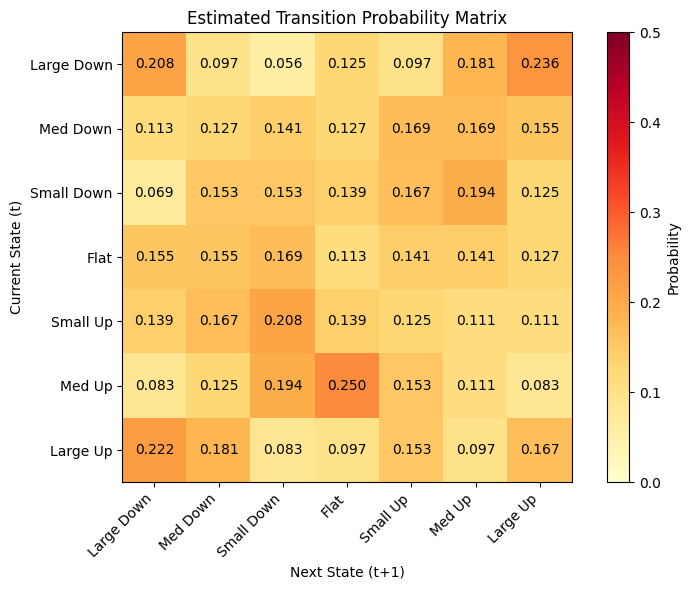

In [ ]:
# ── 11. Transition matrix heatmap ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(P_train, cmap="YlOrRd", vmin=0, vmax=0.5)

ax.set_xticks(range(K))
ax.set_yticks(range(K))
ax.set_xticklabels(state_labels, rotation=45, ha="right")
ax.set_yticklabels(state_labels)
ax.set_xlabel("Next State (t+1)")
ax.set_ylabel("Current State (t)")
ax.set_title("Estimated Transition Probability Matrix")

# Annotate cells
for i in range(K):
    for j in range(K):
        ax.text(j, i, f"{P_train[i,j]:.3f}", ha="center", va="center",
                color="white" if P_train[i,j] > 0.3 else "black", fontsize=10)

plt.colorbar(im, ax=ax, label="Probability")
plt.tight_layout()
plt.show()

# Markov Chain Regime Analysis — S&P 500

We use a **Hidden Markov Model (HMM)** to detect five market regimes — Crisis, Bear, Neutral, Bull, Strong Bull —
directly from SPX daily return data. Each regime is one node in the Markov chain graph, and
the edges represent probabilities of switching between them day to day.

Using five states instead of three makes the model more sensitive to shorter-lived stress events
(like the Feb 2018 "Volmageddon" correction) that a coarser model would absorb into a single
catch-all neutral state. The richer state space also produces a more complex transition graph
with more distinct pathways between regimes.

We train on 2010–2018 to capture genuine regime variation across multiple market cycles
(2010–11 Euro crisis, 2015–16 China volatility, the calm 2017 bull, the Feb 2018 correction,
the Q4 2018 selloff), and test whether the decoded regime signal is useful for trading
individual stocks in 2019.

In [15]:
# pip install hmmlearn  (if needed)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from hmmlearn import hmm
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

In [16]:
REGIMES    = ['Crisis', 'Bear', 'Neutral', 'Bull', 'Strong Bull']
REG_COLORS = {
    'Crisis':      '#b71c1c',
    'Bear':        '#e53935',
    'Neutral':     '#9e9e9e',
    'Bull':        '#43a047',
    'Strong Bull': '#1b5e20',
}

def log_returns(prices):
    return np.log(prices / prices.shift(1))

def annualised_sharpe(rets):
    return rets.mean() / rets.std() * np.sqrt(252) if rets.std() > 0 else 0

def avg_duration(regime_series, regime):
    """Mean consecutive days per visit to a regime."""
    durations, count = [], 0
    for val in (regime_series == regime):
        if val:
            count += 1
        elif count:
            durations.append(count)
            count = 0
    if count:
        durations.append(count)
    return np.mean(durations) if durations else 0

## 1. Data

We download SPX daily closes from 2010 to end of 2018 for training.
This window includes the Euro crisis (2011), steady bull (2012–14),
China volatility spike (2015–16), the ultra-calm 2017, the Feb 2018 correction,
and the Q4 2018 selloff.
That variation is what the HMM needs to separate five distinct regimes reliably.

In [17]:
raw_train = yf.download('^GSPC', start='2010-01-01', end='2019-01-01', progress=False)

# yfinance can return MultiIndex columns — flatten to a simple Series
close = raw_train['Close']
if hasattr(close, 'columns'):   # MultiIndex case
    close = close.iloc[:, 0]

spx = pd.DataFrame({'Close': close})
spx['ret'] = np.log(spx['Close'] / spx['Close'].shift(1))
spx = spx.dropna()
print(f'Training data: {len(spx)} days  ({spx.index[0].date()} to {spx.index[-1].date()})')

Training data: 2263 days  (2010-01-05 to 2018-12-31)


## 2. HMM Regime Detection

**How the HMM works:** The model assumes the market is always in one of K = 5 hidden states (regimes)
and that each day's observed return is drawn from a Gaussian whose mean and variance depend on
the current state. The Markov part is that tomorrow's regime depends only on today's — which is
what gives us the transition matrix and the graph structure.

**Why five states?** With three states, the model's high persistence (97–99% stay probability)
means it resists switching for short-lived events. The Feb 2018 correction — a ~10% drawdown
over two weeks — gets absorbed into the broad "Neutral" bucket. Five states let the model
separate an extreme Crisis state (very high vol) from a milder Bear state, and similarly
distinguish Strong Bull (very calm) from regular Bull. This makes the detection more sensitive
to brief but violent moves.

**What Viterbi does:** Since we cannot directly observe which regime we are in,
we use the Viterbi algorithm to decode the most likely regime sequence from the observed returns.
It works by dynamic programming — at each time step it tracks the most likely path to each state
rather than enumerating all 5^N possible sequences (which would be computationally impossible).

We run multiple random initialisations and keep the model with the best log-likelihood,
which avoids getting stuck in poor local optima.

In [18]:
X = spx['ret'].values.reshape(-1, 1)

N_STATES = 5

# Multiple restarts — keep best converged model
best_score, best_model = -np.inf, None
for seed in range(30):
    m = hmm.GaussianHMM(n_components=N_STATES, covariance_type='diag',
                         n_iter=2000, random_state=seed, tol=1e-5)
    m.fit(X)
    try:
        s = m.score(X)
        if s > best_score:
            best_score, best_model = s, m
    except Exception:
        continue

model = best_model
print(f'Best log-likelihood: {best_score:.2f}')

Model is not converging.  Current: 7676.57435663948 is not greater than 7676.784092581349. Delta is -0.20973594186853006
Model is not converging.  Current: 7706.208842728126 is not greater than 7708.542309219395. Delta is -2.333466491269064
Model is not converging.  Current: 7671.558742960895 is not greater than 7671.594592509257. Delta is -0.035849548362421046
Model is not converging.  Current: 7646.318953478329 is not greater than 7646.356564020093. Delta is -0.03761054176447942
Model is not converging.  Current: 7631.2927674619295 is not greater than 7631.520489406766. Delta is -0.22772194483604835
Model is not converging.  Current: 7634.1870844169325 is not greater than 7634.230535621966. Delta is -0.043451205033306906
Model is not converging.  Current: 7689.827811656246 is not greater than 7689.8372155127245. Delta is -0.009403856478456873
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no tr

Best log-likelihood: 7703.58


In [19]:
# Decode regime sequence via Viterbi
spx['state'] = model.predict(X)

# Label states by mean return: lowest → Crisis, highest → Strong Bull
means = {s: spx.loc[spx['state'] == s, 'ret'].mean() for s in range(N_STATES)}
order = sorted(means, key=means.get)
label_map = {order[i]: REGIMES[i] for i in range(N_STATES)}
spx['regime'] = spx['state'].map(label_map)

for r in REGIMES:
    sub = spx[spx['regime'] == r]
    print(f"{r:12s}: {len(sub):4d} days | "
          f"mean={sub['ret'].mean()*100:+.3f}% | "
          f"vol={sub['ret'].std()*100:.3f}% | "
          f"avg duration={avg_duration(spx['regime'], r):.1f} days")

Crisis      :   25 days | mean=-1.986% | vol=0.641% | avg duration=1.0 days
Bear        :  221 days | mean=-0.160% | vol=1.909% | avg duration=55.2 days
Neutral     :  145 days | mean=-0.064% | vol=1.218% | avg duration=1.0 days
Bull        :  145 days | mean=+0.063% | vol=1.372% | avg duration=1.0 days
Strong Bull : 1727 days | mean=+0.095% | vol=0.595% | avg duration=66.4 days


## 3. Regime Timeline

SPX price with regime shading and daily returns coloured by regime.
With five states we expect the model to flag shorter stress episodes (like the Feb 2018
correction) that could not breach the high persistence threshold of a three-state model.
Crisis should capture the sharpest volatility spikes, Bear the broader stress windows,
Neutral the transitions, and Bull / Strong Bull the calm uptrends.

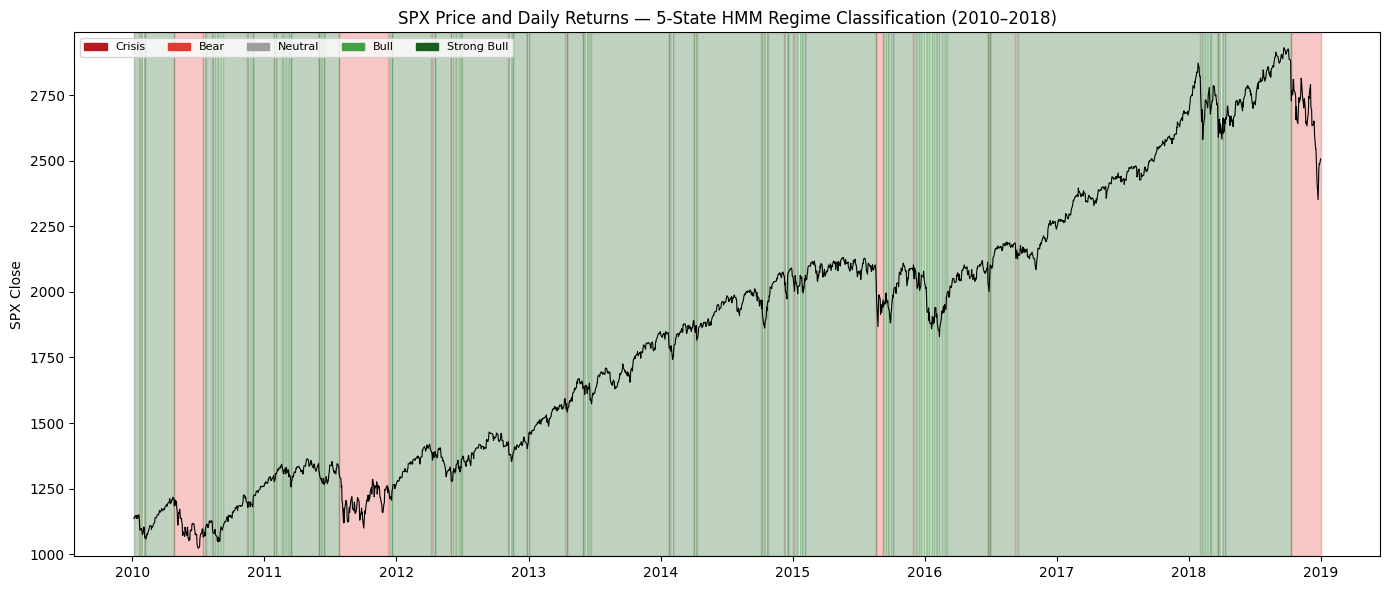

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(14, 6), sharex=True)

ylo = float(spx['Close'].min()) * 0.97
yhi = float(spx['Close'].max()) * 1.02
for regime, color in REG_COLORS.items():
    mask = spx['regime'] == regime
    ax.fill_between(spx.index, ylo, yhi, where=mask, alpha=0.28, color=color)
ax.plot(spx.index, spx['Close'], color='black', lw=0.8)
ax.set_ylim(ylo, yhi)
ax.set_ylabel('SPX Close')
ax.set_title('SPX Price and Daily Returns — 5-State HMM Regime Classification (2010–2018)')
patches = [mpatches.Patch(color=REG_COLORS[r], label=r) for r in REGIMES]
ax.legend(handles=patches, loc='upper left', fontsize=8, ncol=5)


plt.tight_layout()
plt.show()

With five states the model should now flag the Feb 2018 correction as at least Bear or Crisis — the sudden volatility spike that a three-state model smoothed over. The timeline should also show finer distinctions: the very calm 2017 as Strong Bull rather than generic Bull, and the broader but less extreme 2015–16 correction separated from the acute 2011 Crisis. More states mean shorter average durations per regime, which is the cost of higher sensitivity.

## 4. Transition Structure

We estimate the empirical 5×5 transition matrix from the decoded sequence and visualise it as
both a heatmap (precise probabilities) and a directed graph (flow structure).
With five nodes the graph is richer — we can see whether the market must step through
intermediate regimes (e.g. Crisis→Bear→Neutral→Bull→Strong Bull) or whether it sometimes
skips states. Self-loop probabilities on each node indicate regime persistence.

In [21]:
P = np.zeros((N_STATES, N_STATES))
for t in range(len(spx) - 1):
    i = REGIMES.index(spx['regime'].iloc[t])
    j = REGIMES.index(spx['regime'].iloc[t + 1])
    P[i, j] += 1
P = P / P.sum(axis=1, keepdims=True)

print('Transition matrix  (row = current, col = next):')
print(pd.DataFrame(P.round(3), index=REGIMES, columns=REGIMES))

Transition matrix  (row = current, col = next):
             Crisis   Bear  Neutral  Bull  Strong Bull
Crisis        0.000  0.000    1.000   0.0        0.000
Bear          0.014  0.986    0.000   0.0        0.000
Neutral       0.000  0.000    0.000   1.0        0.000
Bull          0.000  0.000    0.828   0.0        0.172
Strong Bull   0.013  0.002    0.000   0.0        0.985


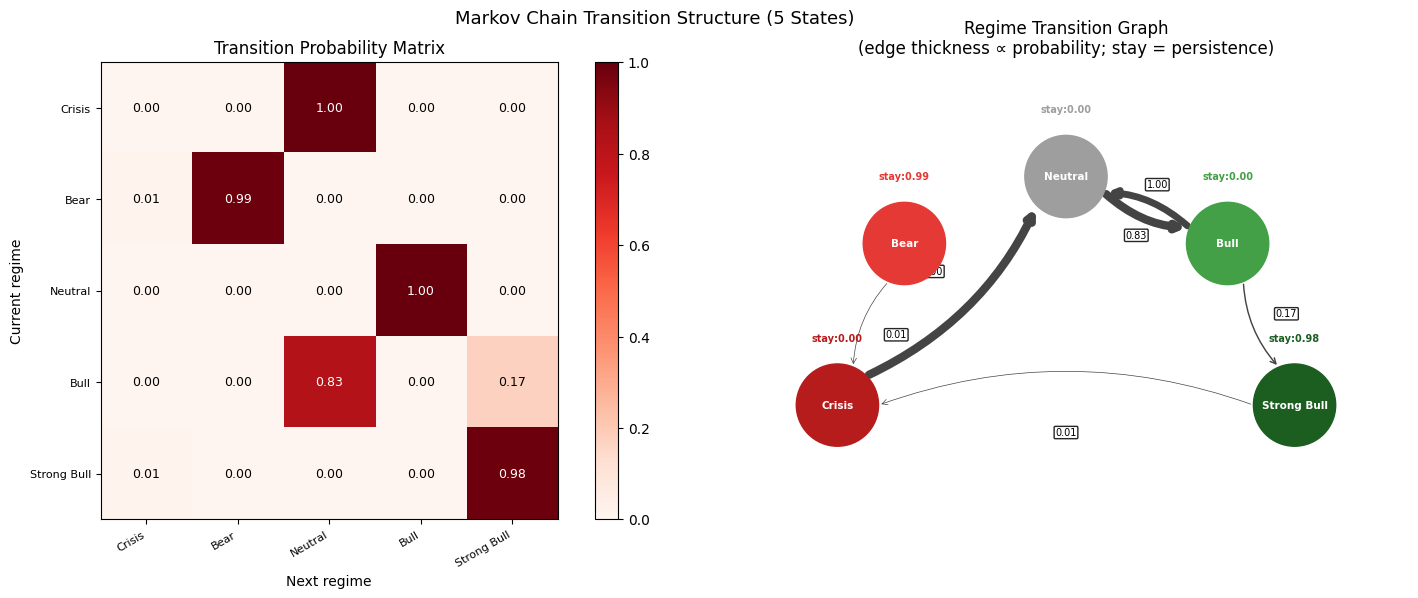

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Heatmap ──
ax = axes[0]
im = ax.imshow(P, cmap='Reds', vmin=0, vmax=1)
ax.set_xticks(range(N_STATES)); ax.set_xticklabels(REGIMES, fontsize=8, rotation=30, ha='right')
ax.set_yticks(range(N_STATES)); ax.set_yticklabels(REGIMES, fontsize=8)
ax.set_xlabel('Next regime'); ax.set_ylabel('Current regime')
ax.set_title('Transition Probability Matrix')
for i in range(N_STATES):
    for j in range(N_STATES):
        ax.text(j, i, f'{P[i,j]:.2f}', ha='center', va='center', fontsize=9,
                color='white' if P[i, j] > 0.55 else 'black')
plt.colorbar(im, ax=ax)

# ── Directed graph — pentagon layout ──
ax = axes[1]
# Place nodes in a semicircle: Crisis far left, Strong Bull far right, Neutral at top
angles = np.linspace(np.pi, 0, N_STATES)
pos = {r: (1.0 * np.cos(a), 1.0 * np.sin(a)) for r, a in zip(REGIMES, angles)}
node_r = 0.18

for i, r1 in enumerate(REGIMES):
    for j, r2 in enumerate(REGIMES):
        if i == j or P[i, j] < 0.005:
            continue
        x1, y1 = pos[r1]; x2, y2 = pos[r2]
        dx, dy = x2 - x1, y2 - y1
        n = (dx**2 + dy**2) ** 0.5
        sx, sy = x1 + node_r * dx / n, y1 + node_r * dy / n
        ex, ey = x2 - node_r * dx / n, y2 - node_r * dy / n
        ax.annotate('', xy=(ex, ey), xytext=(sx, sy),
                    arrowprops=dict(arrowstyle='->', lw=max(P[i, j] * 6, 0.5),
                                    color='#444444', connectionstyle='arc3,rad=0.18'))
        mx, my = (sx + ex) / 2, (sy + ey) / 2
        pdx, pdy = -dy / n, dx / n
        ax.text(mx + 0.12 * pdx, my + 0.12 * pdy, f'{P[i,j]:.2f}',
                fontsize=7, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.12', facecolor='white', alpha=0.85))

for regime, (x, y) in pos.items():
    circle = plt.Circle((x, y), node_r, color=REG_COLORS[regime], zorder=5)
    ax.add_patch(circle)
    ax.text(x, y, regime, ha='center', va='center',
            color='white', fontweight='bold', fontsize=7.5, zorder=6)
    i = REGIMES.index(regime)
    ax.text(x, y + node_r + 0.1, f'stay:{P[i,i]:.2f}',
            ha='center', fontsize=7, color=REG_COLORS[regime], fontweight='bold')

ax.set_xlim(-1.5, 1.5); ax.set_ylim(-0.5, 1.5)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Regime Transition Graph\n(edge thickness ∝ probability; stay = persistence)')

plt.suptitle('Markov Chain Transition Structure (5 States)', fontsize=13)
plt.tight_layout()
plt.show()

With five states the transition graph should be noticeably richer than the three-state version. The key features to look for: (1) high self-loop probabilities on each node — regimes are still persistent enough to be actionable; (2) near-neighbour transitions dominate — the market prefers stepping through adjacent regimes rather than jumping between extremes; (3) possible asymmetries between the crash path (Bull→Neutral→Bear→Crisis) and the recovery path, reflecting the well-known pattern that markets fall fast and recover slowly.

## 5. Regime Characteristics

Mean return, volatility, and average duration per regime.
With five states we expect a clearer volatility spectrum — Crisis should have the highest
vol, Strong Bull the lowest, with the other three in between.

In [23]:
stats = {r: {
    'Days':            int((spx['regime'] == r).sum()),
    'Mean Return (%)': spx.loc[spx['regime'] == r, 'ret'].mean() * 100,
    'Daily Vol (%)':   spx.loc[spx['regime'] == r, 'ret'].std()  * 100,
    'Avg Duration':    avg_duration(spx['regime'], r)
} for r in REGIMES}

stats_df = pd.DataFrame(stats).T
print(stats_df.round(3))

               Days  Mean Return (%)  Daily Vol (%)  Avg Duration
Crisis         25.0           -1.986          0.641         1.000
Bear          221.0           -0.160          1.909        55.250
Neutral       145.0           -0.064          1.218         1.000
Bull          145.0            0.063          1.372         1.000
Strong Bull  1727.0            0.095          0.595        66.423


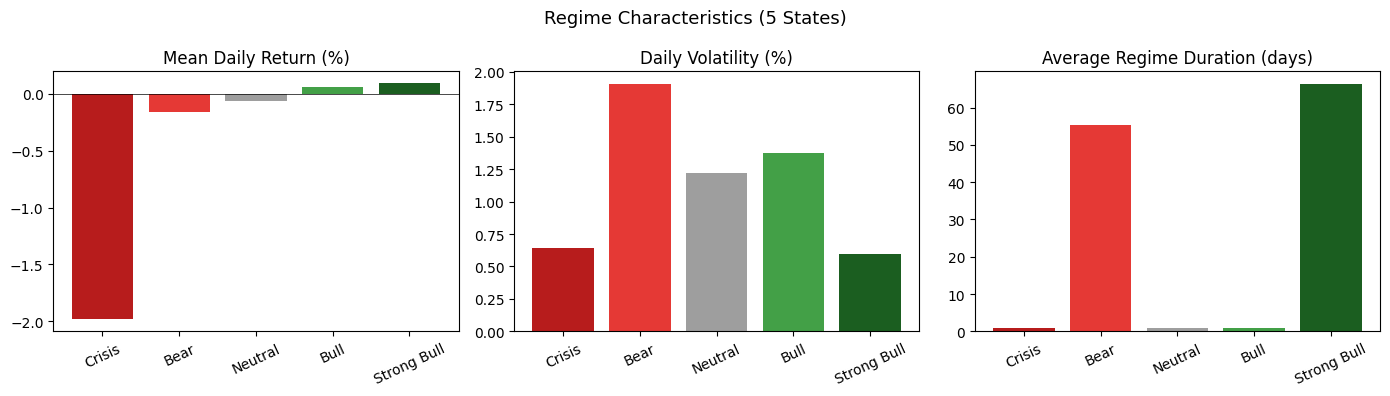

In [24]:
colors = [REG_COLORS[r] for r in REGIMES]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(REGIMES, stats_df['Mean Return (%)'], color=colors)
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_title('Mean Daily Return (%)')
axes[0].tick_params(axis='x', rotation=25)

axes[1].bar(REGIMES, stats_df['Daily Vol (%)'], color=colors)
axes[1].set_title('Daily Volatility (%)')
axes[1].tick_params(axis='x', rotation=25)

axes[2].bar(REGIMES, stats_df['Avg Duration'], color=colors)
axes[2].set_title('Average Regime Duration (days)')
axes[2].tick_params(axis='x', rotation=25)

plt.suptitle('Regime Characteristics (5 States)', fontsize=13)
plt.tight_layout()
plt.show()

The five-state model should reveal a clear volatility spectrum from Crisis (highest) to Strong Bull (lowest). Compared to the three-state version, the additional states allow the model to separate genuine crashes (Crisis) from moderate corrections (Bear), and ultra-calm rallies (Strong Bull) from normal uptrends (Bull). Average durations will be shorter than in the three-state model — this is the expected trade-off for higher sensitivity.

In [25]:
raw_test = yf.download('^GSPC', start='2019-01-01', end='2020-01-01', progress=False)

close_test = raw_test['Close']
if hasattr(close_test, 'columns'):
    close_test = close_test.iloc[:, 0]

spx_test = pd.DataFrame({'Close': close_test})
spx_test['ret'] = np.log(spx_test['Close'] / spx_test['Close'].shift(1))
spx_test = spx_test.dropna()

X_test = spx_test['ret'].values.reshape(-1, 1)

# ── Causal forward filtering — no look-ahead ──
# At each day t, compute P(state_t | r_1, …, r_t) using only past + current data,
# then take argmax.  This is the forward algorithm without the backward smoothing pass.
log_startprob = np.log(model.startprob_)
log_transmat  = np.log(model.transmat_)
framelogprob  = model._compute_log_likelihood(X_test)   # (T, K) emission log-probs

T = len(X_test)
causal_states = np.empty(T, dtype=int)

log_alpha = log_startprob + framelogprob[0]
causal_states[0] = np.argmax(log_alpha)

for t in range(1, T):
    # log_alpha_t(j) = log[ sum_i alpha_{t-1}(i) * A(i,j) ] + log b_j(o_t)
    log_alpha = np.logaddexp.reduce(
        log_alpha[:, None] + log_transmat, axis=0
    ) + framelogprob[t]
    causal_states[t] = np.argmax(log_alpha)

spx_test['state']  = causal_states
spx_test['regime'] = spx_test['state'].map(label_map)

print('2019 regime counts (causal forward filtering):')
print(spx_test['regime'].value_counts())

2019 regime counts (causal forward filtering):
regime
Strong Bull    222
Neutral         15
Bull            10
Crisis           4
Name: count, dtype: int64


In [26]:
STOCKS = ['AAPL', 'MSFT', 'JPM', 'XOM', 'JNJ', 'PG', 'BA', 'GS', 'AMZN', 'CVX']
raw_stocks = yf.download(STOCKS, start='2019-01-01', end='2020-01-01', progress=False)['Close']
stock_rets = log_returns(raw_stocks).dropna()

SIGNAL_MAP = {'Strong Bull': 1.0, 'Bull': 0.5, 'Neutral': 0.0, 'Bear': -0.5, 'Crisis': -1.0}
signal  = spx_test['regime'].map(SIGNAL_MAP)
aligned = stock_rets.join(signal.rename('signal'), how='inner').dropna()

results = []
for ticker in STOCKS:
    if ticker not in aligned.columns:
        continue
    strat = aligned['signal'] * aligned[ticker]
    bh    = aligned[ticker]
    results.append({
        'Ticker':              ticker,
        'Strategy Sharpe':     annualised_sharpe(strat),
        'B&H Sharpe':          annualised_sharpe(bh),
        'Strategy Return (%)': (np.exp(strat.sum()) - 1) * 100,
        'B&H Return (%)':      (np.exp(bh.sum())   - 1) * 100,
    })

results_df = pd.DataFrame(results).set_index('Ticker')
print(results_df.round(3))

        Strategy Sharpe  B&H Sharpe  Strategy Return (%)  B&H Return (%)
Ticker                                                                  
AAPL              2.916       2.420              102.851          88.742
MSFT              2.552       2.322               58.413          58.259
JPM               3.036       1.991               65.423          44.751
XOM               0.546       0.264                9.316           4.925
JNJ               1.117       0.973               18.686          17.403
PG                2.048       2.080               36.696          40.680
BA                0.258       0.099                7.489           2.920
GS                2.213       1.333               61.441          36.412
AMZN              0.990       0.804               23.474          20.057
CVX               1.173       0.682               21.702          13.295


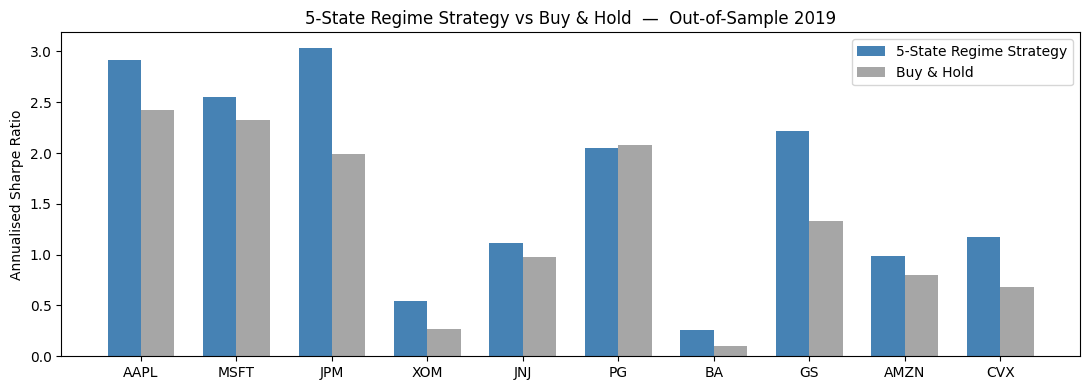

In [27]:
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(results_df))
w = 0.35

ax.bar(x - w/2, results_df['Strategy Sharpe'], w, label='5-State Regime Strategy', color='steelblue')
ax.bar(x + w/2, results_df['B&H Sharpe'],      w, label='Buy & Hold',              color='grey', alpha=0.7)
ax.axhline(0, color='black', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(results_df.index)
ax.set_ylabel('Annualised Sharpe Ratio')
ax.set_title('5-State Regime Strategy vs Buy & Hold  —  Out-of-Sample 2019')
ax.legend()
plt.tight_layout()
plt.show()